# Introduction
This Coursera Lab Jupyter notebook implements the spring-mass-damper model that we will use as an example system for this week of the course (and in the next course also). It defines the model constants and then simulates the model for a sinusoidal input signal.

Don't forget that to execute the Octave code in any cell, depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell. I refer to this as "< shift \> < enter \>" in my instructions below.

### Defining the constants and setting up the problem
The next notebook cell defines the state-space model and the simulation settings. Place the cursor inside the cell and depress < shift > < enter >. Do the same for the following cells to execute their contents.

In [1]:
m = 50; b = 2; k = 4; % Specify physical constants
A = [0 1; -k/m -b/m]; % Specify continuous-time model
B = [0; 1/m]; Bw = B;
C = [1 0]; D = 0;

dT = 0.1;             % Create discrete-time model
Ad = expm(A*dT); 
Bd = inv(A)*(Ad-eye(2))*B;
Cd = C; Dd = D;

Sw = 0.01; Sv = 1e-5;            % Specify noise model
Z = [-A Bw*Sw*Bw'; zeros(2) A']; % convert to discrete-time
C = expm(Z*dT); 
c12 = C(1:2,3:4); c22 = C(3:4,3:4);
SigmaW = c22'*c12; SigmaV = Sv/dT; 

numSims = 5;          % Define the number of simulations to run
fprintf('Finished defining the model\n');

Finished defining the model


### Run simulation
The next notebook cell runs the simulations.

In [2]:
t = 0:dT:100;              % Set up the simulation time vector
u = sin(2*pi*(1/10)*t);    % Set up the deterministic system input
nt = length(t);            % Length of the time vector
randn("state",0);          % Don't change this line! It is needed for computing correct quiz inputs

x = zeros(2,nt+1,numSims); % Reserve storage for the state profiles for all simulations
z = zeros(nt,numSims);     % Reserve storage for the output for all simulations
for theSim = 1:numSims     % Execute "numSims" simulations with different random noises
  for k = 1:length(t)      % This is the kth step for each simulation
    x(:,k+1,theSim) = Ad*x(:,k,theSim) + Bd*u(k) + chol(SigmaW,'lower')*randn(2,1);
    z(k,theSim)     = Cd*x(:,k,theSim) + Dd*u(k) + chol(SigmaV,'lower')*randn(1);
  end
end
x = x(:,1:nt,:);           % Crop the states to the same length as "t".
fprintf('Finished running the simulations\n');

Finished running the simulations


### Plot simulation variables
The next notebook cells plot the state-vector components and the output measurement.

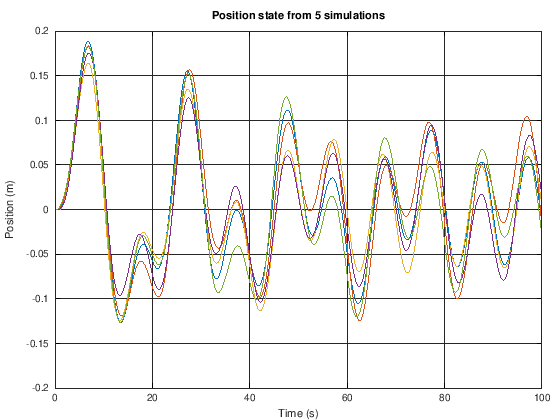

In [3]:
% Plot x1(k), the position state
plot(t,squeeze(x(1,:,:))); grid on
title(sprintf('Position state from %d simulations',numSims));
xlabel('Time (s)'); ylabel('Position (m)');

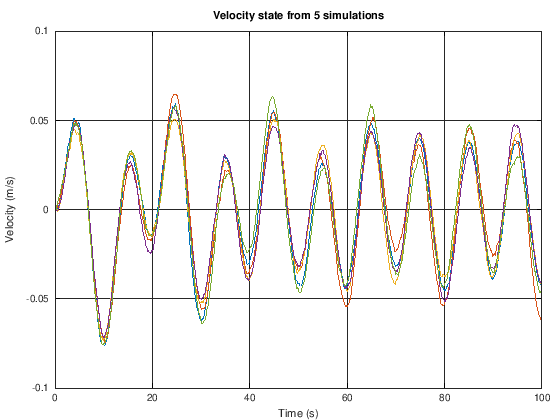

In [4]:
% Plot x2(k), the velocity state
plot(t,squeeze(x(2,:,:))); grid on
title(sprintf('Velocity state from %d simulations',numSims));
xlabel('Time (s)'); ylabel('Velocity (m/s)');

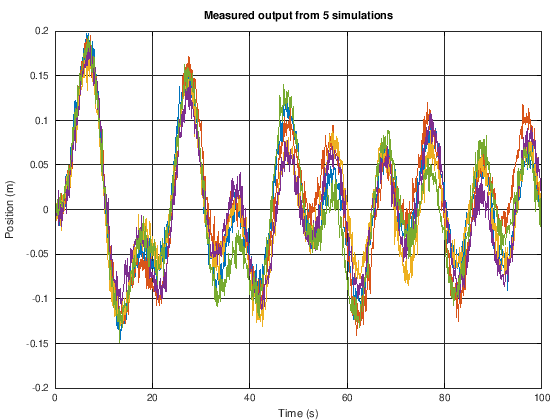

In [5]:
% Plot z(k), the measured output
plot(t,z); grid on
title(sprintf('Measured output from %d simulations',numSims));
xlabel('Time (s)'); ylabel('Position (m)');

### User workspace
You can enter your own Octave commands into the next cell to query variables, plot results, or anything you like.